# Week 12

`bgg_1k.csv` contains information about the top 1000 boardgames, taken from https://boardgamegeek.com/.

## Challenges
1. Run a topic model on `description`. You might need to refine the topic model (eg there might be junk topic you need to remove, similar topic you want to merge together, or there are simply too many topics and you want to do a topic reduction), check out https://maartengr.github.io/BERTopic/getting_started/topicreduction/topicreduction.html and refine your topic model
2. What is the most popular topic among the board games?
3. `bg_ranks.csv` contains more information on the board games, for example, ratings (yes, you need to merge two datasets). Find out if there are differences in rating across topics? Make a graph to show it!
4. Any insights you gain from this exercises (what you have learnt about the board games)? Share!

PS: you need to combine what you have learnt so far to do this week's challenges

In [73]:
import pandas as pd
df = pd.read_csv('threads.csv')
df.head()

,nav_index,item_id,timestamp_collected,source_platform,source_platform_url,source_url,user_agent,datapk,datauserfriendship_statusmuting,datauserfriendship_statusfollowing,...,datagiphy_media_info,dataprototyping_only_glimmer_post_info,dataoriginal_lang_for_translations,datametaPlace,datameta_place,datagen_ai_detection_methoddetection_method,dataorganic_tracking_token,data__token,datalike_and_view_counts_disabled,id
0,30:3:NaN,3896318806112464300_63220773849,1778744197966,threads.net,https://www.threads.com/search?q=%E6%B7%A1%E6%...,https://www.threads.com/search?q=%E6%B7%A1%E6%...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; ...,3896318806112464300,False,False,...,NaN,NaN,NaN,NaN,NaN,NONE,eyJ2ZXJzaW9uIjo1LCJwYXlsb2FkIjp7ImlzX2FuYWx5dG...,NaN,False,1029
1,30:3:NaN,3895312899531331594_63396255559,1778744197967,threads.net,https://www.threads.com/search?q=%E6%B7%A1%E6%...,https://www.threads.com/search?q=%E6%B7%A1%E6%...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; ...,3895312899531331594,False,False,...,NaN,NaN,NaN,NaN,NaN,NONE,eyJ2ZXJzaW9uIjo1LCJwYXlsb2FkIjp7ImlzX2FuYWx5dG...,NaN,False,1030
2,30:3:NaN,3895944903213540942_76411925439,1778744197967,threads.net,https://www.threads.com/search?q=%E6%B7%A1%E6%...,https://www.threads.com/search?q=%E6%B7%A1%E6%...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; ...,3895944903213540942,False,False,...,NaN,NaN,NaN,NaN,NaN,NONE,eyJ2ZXJzaW9uIjo1LCJwYXlsb2FkIjp7ImlzX2FuYWx5dG...,NaN,False,1031
3,30:3:NaN,3896072529207341938_67706365049,1778744197968,threads.net,https://www.threads.com/search?q=%E6%B7%A1%E6%...,https://www.threads.com/search?q=%E6%B7%A1%E6%...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; ...,3896072529207341938,False,False,...,NaN,NaN,NaN,NaN,NaN,NONE,eyJ2ZXJzaW9uIjo1LCJwYXlsb2FkIjp7ImlzX2FuYWx5dG...,NaN,False,1032
4,30:3:NaN,3879566296752948258_63964772678,1778744197968,threads.net,https://www.threads.com/search?q=%E6%B7%A1%E6%...,https://www.threads.com/search?q=%E6%B7%A1%E6%...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; ...,3879566296752948258,False,False,...,NaN,NaN,NaN,NaN,NaN,NONE,eyJ2ZXJzaW9uIjo1LCJwYXlsb2FkIjp7ImlzX2FuYWx5dG...,NaN,False,1033


In [74]:
docs = df['datatext_post_app_infotext_fragmentsfragments0plaintext'].tolist()

In [75]:
docs[0]

'我這邊沒什麼流量，只是寫下自己\u200b對於台灣交通體制與社會氛圍的現狀，有幾個點會讓真心為台灣好的人感到灰心。\\n\\n淡江大橋作為受矚目的地標，其機車道的配置爭議，反映出的是長期以來台灣交通規劃中「車種分流」與「安全管理」之間的邏輯矛盾。是整個交通系統長期設計失敗，導致大家只能在錯的環境裡互相傷害。\\n\\n1. 台灣高度依賴機車，但制度把機車當次等公民\\n機車使用率世界級高，但道路設計卻長期偏向汽車，很多地方要嘛把機車趕去邊邊擠，要嘛直接不給走，久了自然產生「你不該在這裡」的觀感'

In [76]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
sentence_model = SentenceTransformer("distiluse-base-multilingual-cased-v2") # 
embeddings = sentence_model.encode(docs, show_progress_bar=True)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

In [79]:
topic_model = BERTopic(language="multilingual",
                       verbose=True)
topics, probs = topic_model.fit_transform(docs, embeddings)
topic_model.get_topic_info().head(50)

2026-05-14 15:41:47,923 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-14 15:41:48,028 - BERTopic - Dimensionality - Completed ✓
2026-05-14 15:41:48,029 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-14 15:41:48,053 - BERTopic - Cluster - Completed ✓
2026-05-14 15:41:48,058 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-14 15:41:48,073 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,56,-1_淡江大橋_zaha_n1_竟整個人橫躺在機車道上,"[淡江大橋, zaha, n1, 竟整個人橫躺在機車道上, 平流雲海, 有交通專業, 危險啦...",[淡江大橋今天通車，昨天被火花羅等人發現護欄有嚴重缺失，結果公路總局的作法不是認錯，而是造謠...


In [78]:
topic_model.visualize_barchart(top_n_topics = 50)

ValueError: 
The 'rows' argument to make_subplots must be an int greater than 0.
    Received value of type <class 'int'>: 0

In [53]:
df['topic'] = topics

In [54]:
ranks = pd.read_csv('bg_ranks.csv')

In [63]:
ranks.head()

,id,name,yearpublished,rank,bayesaverage,average,usersrated,is_expansion,abstracts_rank,cgs_rank,childrensgames_rank,familygames_rank,partygames_rank,strategygames_rank,thematic_rank,wargames_rank
0,224517,Brass: Birmingham,2018,1,8.39364,8.56439,58232,0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
1,342942,Ark Nova,2021,2,8.35498,8.54083,60764,0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
2,161936,Pandemic Legacy: Season 1,2015,3,8.34640,8.50274,57340,0,NaN,NaN,NaN,NaN,NaN,3.0,1.0,NaN
3,174430,Gloomhaven,2017,4,8.29787,8.53992,67090,0,NaN,NaN,NaN,NaN,NaN,5.0,2.0,NaN
4,397598,Dune: Imperium – Uprising,2023,5,8.23598,8.70122,18182,0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN


In [70]:
df = df.merge(ranks[['id','rank','bayesaverage','usersrated']], on = 'id')

In [71]:
df['z_score'] = (df['bayesaverage'] - df['bayesaverage'].mean()) / df['bayesaverage'].std()


<Axes: xlabel='topic', ylabel='z_score'>

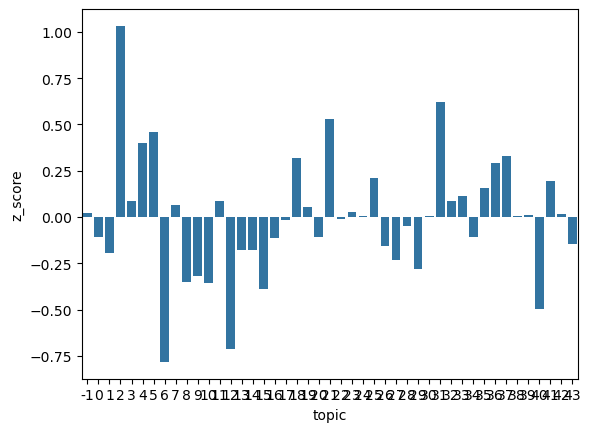

In [72]:
import seaborn as sns

# Group and aggregate
df_grouped = df.groupby('topic')['z_score'].mean().reset_index()

# Plot using Seaborn
sns.barplot(data=df_grouped, x='topic', y='z_score')

In [68]:
df_grouped.sort_values('usersrated', ascending=False)

,topic,usersrated
41,40,33965.500000
19,18,29244.375000
26,25,22301.142857
16,15,22112.038462
5,4,20041.200000
6,5,19483.125000
34,33,19375.076923
40,39,19278.909091
1,0,19084.913043
27,26,18563.000000
